## Etape - 1 Data prpreparation



In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import json
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
import tensorflow as tf  # optionnel


In [2]:



csv_path = Path("..") / "train.csv"

try:
    mmc = pd.read_csv(csv_path)
    print("Lecture normale OK")
except pd.errors.ParserError:
    mmc = pd.read_csv(csv_path, engine="python", on_bad_lines="skip")

print("Shape:", mmc.shape)
mmc.head()

Shape: (29918, 3)


,ImageID,Labels,Caption
0,0.jpg,1,Woman in swim suit holding parasol on sunny day.
1,1.jpg,1 19,A couple of men riding horses on top of a gree...
2,2.jpg,1,They are brave for riding in the jungle on tho...
3,3.jpg,8 3 13,a black and silver clock tower at an intersect...
4,4.jpg,8 3 7,A train coming to a stop on the tracks out side.


All Labels: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19]
{
  "1": 22755,
  "19": 1020,
  "8": 2203,
  "3": 4345,
  "13": 588,
  "7": 1217,
  "5": 1128,
  "4": 1271,
  "18": 1521,
  "15": 1928,
  "6": 1388,
  "9": 1041,
  "17": 1428,
  "10": 1458,
  "2": 1160,
  "16": 1097,
  "14": 252,
  "11": 597
}


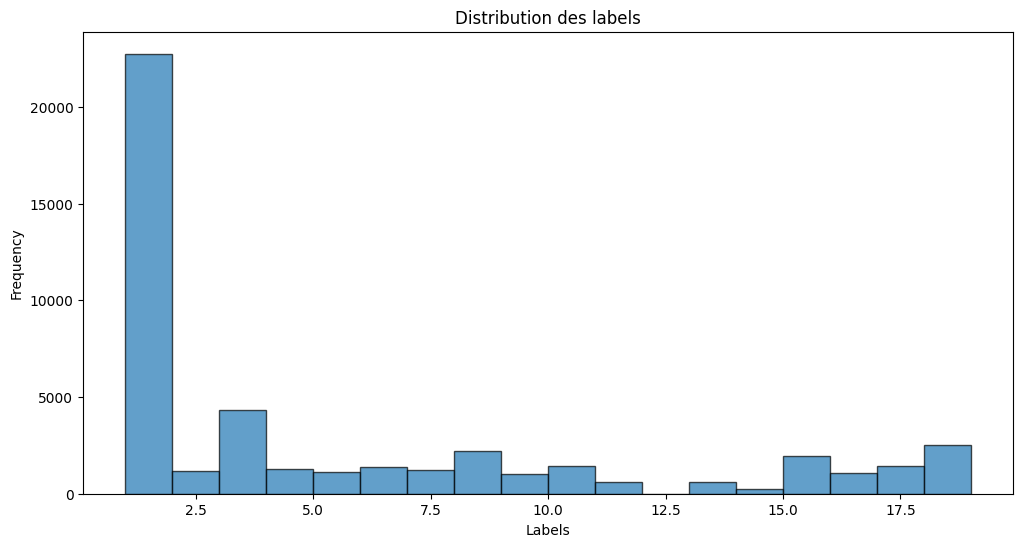

In [3]:
mmc["Labels_list"] = mmc["Labels"].astype(str).str.split().apply(lambda xs: [int(x) for x in xs])
all_labels = sorted({x for row in mmc["Labels_list"] for x in row})
print("All Labels:", all_labels)

labels_flat = [x for row in mmc["Labels_list"] for x in row]
count_dict = Counter(labels_flat)
print(json.dumps(count_dict, indent=2))

plt.figure(figsize=(12, 6))
plt.hist(labels_flat, bins=len(all_labels), edgecolor="black", alpha=0.7)
plt.xlabel("Labels")
plt.ylabel("Frequency")
plt.title("Distribution des labels")
plt.show()

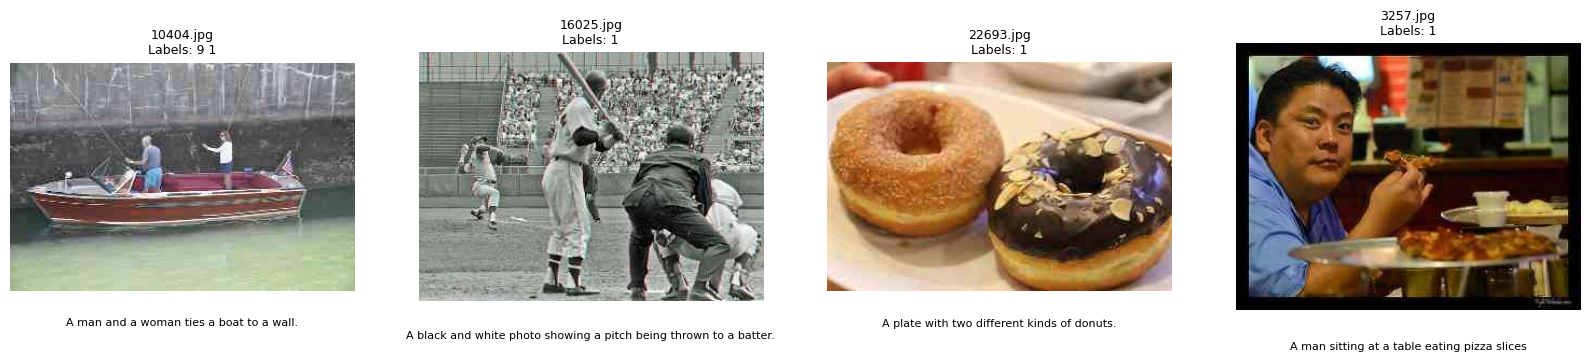

In [4]:

IMAGE_DIR = Path(r"C:\Users\mupps\Desktop\COMP5329S1A2Dataset\data")

num_samples = 4
sampled_df = mmc.sample(num_samples, random_state=42).reset_index(drop=True)

fig, axes = plt.subplots(1, num_samples, figsize=(16, 5))

for i, row in sampled_df.iterrows():
    img_path = IMAGE_DIR / row["ImageID"]

    axes[i].axis("off")

    if img_path.exists():
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].set_title(
            f'{row["ImageID"]}\nLabels: {row["Labels"]}',
            fontsize=9
        )
        axes[i].text(
            0.5, -0.12, row["Caption"],
            ha="center", va="top",
            fontsize=8,
            wrap=True,
            transform=axes[i].transAxes
        )
    else:
        axes[i].text(
            0.5, 0.5, f"Image introuvable\n{row['ImageID']}",
            ha="center", va="center",
            fontsize=10,
            transform=axes[i].transAxes
        )

plt.tight_layout()
plt.show()

In [5]:
NUM_CLASSES = max(all_labels) + 1  # ou len(all_labels) si labels contigus

def multi_hot(label_list, n_classes):
    vec = np.zeros(n_classes, dtype=np.float32)
    for l in label_list:
        vec[l] = 1.0
    return vec

mmc["multi_hot"] = mmc["Labels_list"].apply(lambda x: multi_hot(x, NUM_CLASSES))

print("Exemple multi-hot pour la première ligne:")
print(f"  Labels: {mmc['Labels_list'].iloc[0]}")
print(f"  Vecteur: {mmc['multi_hot'].iloc[0]}")
print(f"  Shape vecteur: {mmc['multi_hot'].iloc[0].shape}")

Exemple multi-hot pour la première ligne:
  Labels: [1]
  Vecteur: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  Shape vecteur: (20,)


In [6]:
train_df, temp_df = train_test_split(mmc, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Train:      {len(train_df)} exemples")
print(f"Validation: {len(val_df)} exemples")
print(f"Test:       {len(test_df)} exemples")

Train:      23934 exemples
Validation: 2992 exemples
Test:       2992 exemples


Longueur moyenne des captions: 10.5 mots
Max: 49 | Min: 7


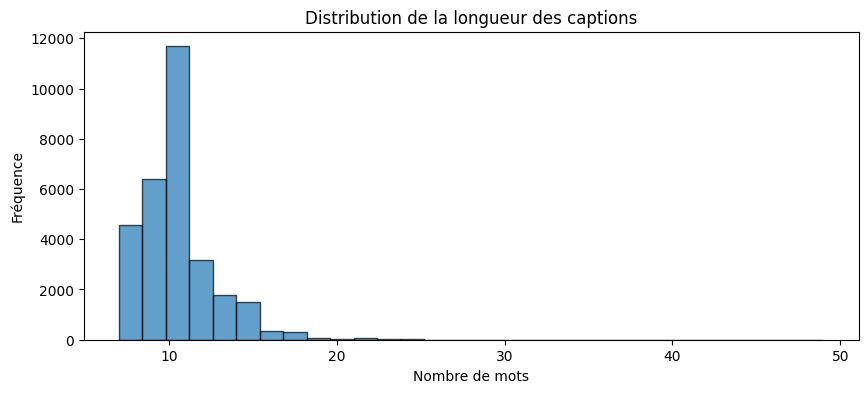

In [7]:
# Important pour la parti LSTM.
mmc["caption_len"] = mmc["Caption"].astype(str).str.split().str.len()

print(f"Longueur moyenne des captions: {mmc['caption_len'].mean():.1f} mots")
print(f"Max: {mmc['caption_len'].max()} | Min: {mmc['caption_len'].min()}")

plt.figure(figsize=(10, 4))
plt.hist(mmc["caption_len"], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel("Nombre de mots")
plt.ylabel("Fréquence")
plt.title("Distribution de la longueur des captions")
plt.show()

In [8]:
# 1) Controle qualite global du dataset
expected_cols = {"ImageID", "Labels", "Caption"}
missing_cols = expected_cols - set(mmc.columns)

print("Colonnes manquantes:", missing_cols if missing_cols else "Aucune")
print("\nValeurs manquantes:")
print(mmc[["ImageID", "Labels", "Caption"]].isna().sum())

print("\nDoublons ImageID:", mmc["ImageID"].duplicated().sum())
print("Shape avant nettoyage:", mmc.shape)

Colonnes manquantes: Aucune

Valeurs manquantes:
ImageID    0
Labels     0
Caption    0
dtype: int64

Doublons ImageID: 0
Shape avant nettoyage: (29918, 6)


In [9]:
# 2) Nettoyage minimal des champs bruts
mmc["ImageID"] = mmc["ImageID"].astype(str).str.strip()
mmc["Labels"] = mmc["Labels"].astype(str).str.strip()
mmc["Caption"] = (
    mmc["Caption"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# Retirer lignes invalides (vides)
mmc = mmc[
    (mmc["ImageID"] != "") &
    (mmc["Labels"] != "") &
    (mmc["Caption"] != "")
].copy()

print("Shape apres nettoyage:", mmc.shape)
mmc.head(10)

Shape apres nettoyage: (29918, 6)


,ImageID,Labels,Caption,Labels_list,multi_hot,caption_len
0,0.jpg,1,Woman in swim suit holding parasol on sunny day.,[1],"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",9
1,1.jpg,1 19,A couple of men riding horses on top of a gree...,"[1, 19]","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",12
2,2.jpg,1,They are brave for riding in the jungle on tho...,[1],"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",11
3,3.jpg,8 3 13,a black and silver clock tower at an intersect...,"[8, 3, 13]","[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...",12
4,4.jpg,8 3 7,A train coming to a stop on the tracks out side.,"[8, 3, 7]","[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, ...",11
5,5.jpg,1,A young man riding a skateboard into the air.,[1],"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",9
6,6.jpg,5,A big airplane flying in the big blue sky,[5],"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...",9
7,7.jpg,1 4,A man riding a motor bike across a forest.,"[1, 4]","[0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...",9
8,8.jpg,8 3,There is a street lined with packed buildings,"[8, 3]","[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...",8
9,9.jpg,1 18 15,A skate park next to a body of water and green...,"[1, 18, 15]","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",12


### Process label
